LR_Scheduler 

In [1]:
import os
import torch
import pandas as pd
from torchvision.io import decode_image
from torch.utils.data import Dataset
import torch.nn.functional as F
from torchvision.transforms import v2
from torch import nn
from torch import optim 


In [2]:
class MyModel(nn.Module):
    def __init__(self, input, output):
        super().__init__()
        self.linear_model = nn.Sequential(nn.Linear(input,128),
                                     nn.ReLU(),
                                     nn.Linear(128,output))
    def forward(self,x):
        return self.linear_model(x)

In [3]:
model = MyModel(784,10)

In [4]:
loss = torch.full([5,10],0.1)
loss = loss * torch.tensor([1/i for i in range(1,6)]).reshape([5,1])
loss = loss.reshape([50])
print(loss)

tensor([0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000, 0.1000,
        0.1000, 0.0500, 0.0500, 0.0500, 0.0500, 0.0500, 0.0500, 0.0500, 0.0500,
        0.0500, 0.0500, 0.0333, 0.0333, 0.0333, 0.0333, 0.0333, 0.0333, 0.0333,
        0.0333, 0.0333, 0.0333, 0.0250, 0.0250, 0.0250, 0.0250, 0.0250, 0.0250,
        0.0250, 0.0250, 0.0250, 0.0250, 0.0200, 0.0200, 0.0200, 0.0200, 0.0200,
        0.0200, 0.0200, 0.0200, 0.0200, 0.0200])


In [5]:
# Создаём 4 независимых оптимайзера
opt1 = optim.Adam(model.parameters(), lr=0.1)
opt2 = optim.Adam(model.parameters(), lr=0.1)
opt3 = optim.Adam(model.parameters(), lr=0.1)
opt4 = optim.Adam(model.parameters(), lr=0.1)

lr_scheduler   = optim.lr_scheduler.ReduceLROnPlateau(opt1, mode='min', factor=0.1, patience=5)
scheduler_exp  = optim.lr_scheduler.ExponentialLR(opt2, gamma=0.95)
scheduler_cos  = optim.lr_scheduler.CosineAnnealingLR(opt3, T_max=50, eta_min=1e-6)
scheduler_cyc  = optim.lr_scheduler.CyclicLR(opt4, base_lr=1e-4, max_lr=0.1, step_size_up=10)


In [6]:
list_ = []
list_exp = []
list_cos = []
list_cyc = []

for epoch in range(50):
    lr_scheduler.step(loss[epoch])
    scheduler_exp.step()
    scheduler_cos.step()
    scheduler_cyc.step()

    list_.append(opt1.param_groups[0]['lr'])  # так надёжнее для ReduceLROnPlateau
    list_exp.append(scheduler_exp.get_last_lr()[0])
    list_cos.append(scheduler_cos.get_last_lr()[0])
    list_cyc.append(scheduler_cyc.get_last_lr()[0])

c:\Users\Honor\miniconda3\envs\PyTotch\Lib\site-packages\torch\optim\lr_scheduler.py:224: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  warnings.warn(


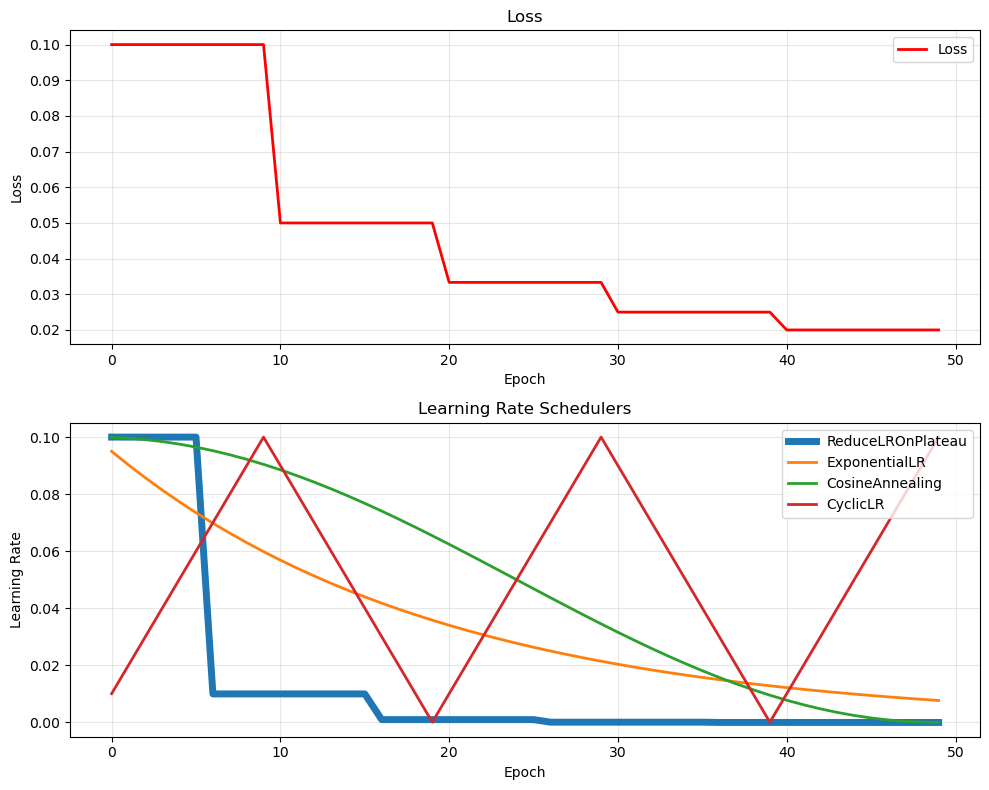

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(10, 8))

# --- График loss (красный) ---
axes[0].plot( loss, color='red', linewidth=2, label='Loss')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# --- Графики learning rate ---
axes[1].plot(list_,  label='ReduceLROnPlateau', linewidth=5)
axes[1].plot(list_exp, label='ExponentialLR',   linewidth=2)
axes[1].plot(list_cos, label='CosineAnnealing', linewidth=2)
axes[1].plot(list_cyc, label='CyclicLR',        linewidth=2)
axes[1].set_title('Learning Rate Schedulers')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Learning Rate')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

были использованы абсолютно синтетические данные просто что бы посмотреть на зависимость выбора шага от ПЛАНИРОВЩИКА и как это соотносится с ф-ей потерь, вообще говоря можно опираться не только на ф-ю потерь но и на другие метрики оцениваюзие качество модели